[1 1 0 2 1 2 0 2 0 0 0 2 0 0 1 0 1 2 0 0 0 0 2 1 0 1 1 2 2 0 0 0 1 0 1 0 1
 2 1 2 2 0 1 2 0 0 1 2 1 2 2 1 1 0 1 2 1 0 2 0 1 2 2 1 1 2 2 1 1 0 2 1 1 0
 0 1 1 2 0 2 0 0 1 0 2 1 1 0 2 0 1 0 1 0 0 1 1 0 1 1 2 0 2 0 0 0 0 0 2 1 2
 0 0 0 0 2 1 2 1 2 2 2 0 1 1 1 1 0 1 1 0 0 0 0 0 2 2 1 0 1 0 0 1 0 2 2 2 0
 2 0 0 1 2 1 0 2 2 1 1 0 0 1 1 1 0 1 2 0 0 0 0 0 2 0 2 2 2 0 2 2 1 0 1 2 2
 1 2 0 2 2 1 1 2 1 2 2 2 2 0 1 0 0 2 2 0 2 1 1 2 0 0 1 2 2 1 1 1 1 0 1 1 2
 1 1 0 2 1 1 2 0 0 1 0 1 2 2 1 2 1 1 1 2 2 0 1 2 2 2 1 2 1 2 1 2 2 1 2 0 1
 0 0 0 1 0 2 2 1 2 2 0 0 2 2 2 1 1 1 0 0 0 2 2 2 2 1 2 1 2 2 1 0 2 2 0 1 0
 2 0 1 1]
18.263159330895952
0.8482330810203894
4730.173967940951


d:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


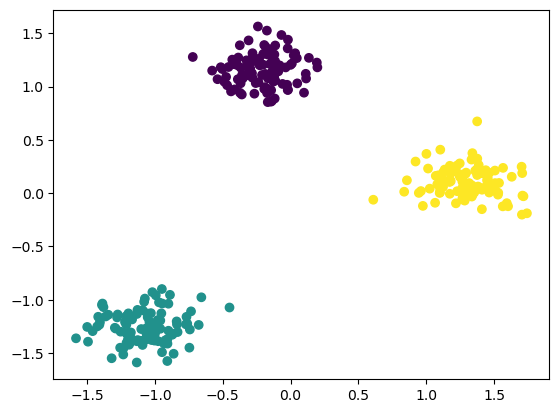

In [ ]:
#实战聚类
from sklearn.cluster import KMeans, k_means
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.metrics import calinski_harabasz_score
import matplotlib.pyplot as plt

# 生成模拟数据
X, _ = make_blobs(n_samples=300, n_features=2, centers=3, cluster_std=1.0,  random_state=42)

# 数据标准化
sd = StandardScaler()
X = sd.fit_transform(X)

# 构建并训练KMeans模型
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)

# 预测聚类标签
labels = kmeans.predict(X)
print(labels)

# 打印聚类评估指标
print(kmeans.inertia_)
print(silhouette_score(X, labels))
print(calinski_harabasz_score(X, labels))

# 可视化聚类结果
plt.scatter(X[:, 0], X[:, 1], c=labels)

d:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
d:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
d:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
d:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than availabl

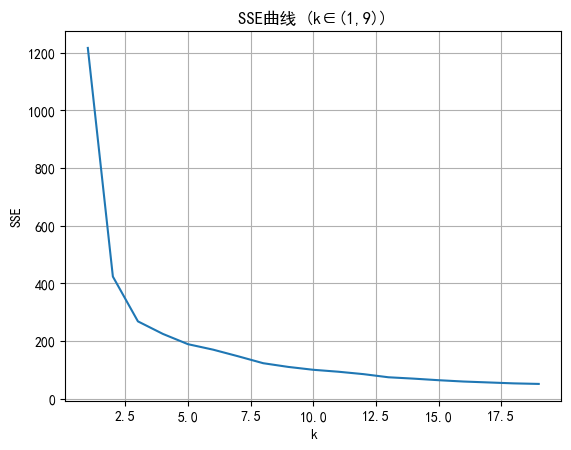

In [7]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import numpy as np

# 生成模拟聚类数据
X, y = make_blobs(n_samples=400, n_features=4 , centers=[[-1,-1],[0,0],[1,1],[2,2]], cluster_std=0.60, random_state=0)

# 计算不同k值下的SSE（簇内平方和）
SSE = []
for k in range(1, 20):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    SSE.append(kmeans.inertia_)

# 绘制SSE曲线图
plt.plot(range(1, 20), SSE)
plt.xlabel('k')
plt.ylabel('SSE')
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置为黑体以显示中文
plt.rcParams['axes.unicode_minus'] = False    # 正常显示负号
plt.title('SSE曲线 (k∈(1,9))')
plt.grid(True)
plt.show()


d:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than availabl

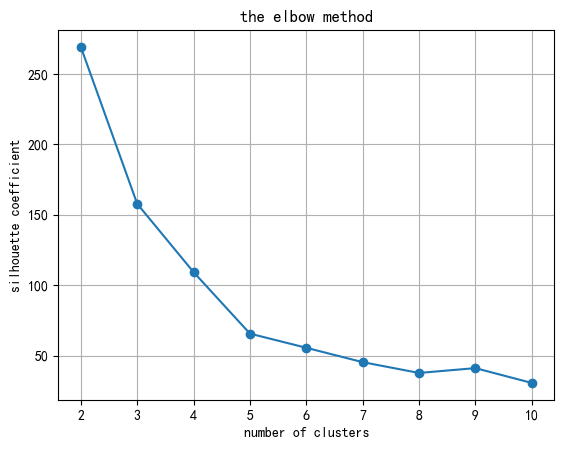

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.metrics import calinski_harabasz_score

# 读取客户数据并展示前几行
data = pd.read_csv('data/customers.csv')
data.head()

# 选取用于聚类的特征：年收入与消费评分
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

# 标准化特征数据
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 初始化列表存储不同聚类数下的SSE与轮廓系数
SSE = []
SC = []
for k in range(2, 11):
    estimator = KMeans(n_clusters=k)
    estimator.fit(X_scaled)
    SSE.append(estimator.inertia_)
    SC.append(silhouette_score(X_scaled, estimator.labels_))

# 绘制肘部法则曲线（SSE随聚类数变化）
plt.plot(range(2, 11), SSE, 'o-')
# plt.plot(range(2, 11), SC, 'o-')

# 设置图表标题与坐标轴标签
plt.title("the elbow method")
plt.xlabel("number of clusters")
plt.ylabel("silhouette coefficient")
plt.grid()
plt.show()